# Analisis Konten Instagram Kompetitor  
## Fokus: CTA, Target Market, dan Caption Labeling (Per Kompetitor)

Notebook ini bertujuan untuk menganalisis  Instagram
dari beberapa kompetitor (Compas, Frontier, Infovesta, Poltracking, Populix)
berdasarkan tiga dimensi utama:

1. **Caption Labeling** – fokus konten & penawaran
2. **CTA Type** – indikasi go-to-market (sales-led vs product-led)
3. **Target Market** – segmen audiens yang disasar

Analisis dilakukan **terpisah per ownerUsername** agar tidak terjadi bias
akibat pencampuran strategi.


# Library

In [1]:
import pandas as pd
import re
from collections import Counter
from IPython.display import display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.1f}")

# Load Data

In [2]:
df_raw = pd.read_csv("C:/MAGANG/Project/210120026-BeData/Raw Data/dataset_instagram-scraper_2026-01-28_13-46-33-230.csv", low_memory=False)
df_raw.columns


Index(['alt', 'audioUrl', 'caption', 'childPosts/0/alt', 'childPosts/0/audioUrl', 'childPosts/0/caption', 'childPosts/0/commentsCount', 'childPosts/0/dimensionsHeight',
       'childPosts/0/dimensionsWidth', 'childPosts/0/displayUrl',
       ...
       'taggedUsers/19/is_verified', 'taggedUsers/19/profile_pic_url', 'taggedUsers/19/username', 'timestamp', 'type', 'url', 'videoDuration', 'videoPlayCount', 'videoUrl', 'videoViewCount'],
      dtype='str', length=2000)

In [3]:
df = pd.read_csv("C:/MAGANG/Project/210120026-BeData/Raw Data/dataset_post.csv", low_memory=False)
df.columns


Index(['caption', 'inputUrl', 'ownerFullName', 'ownerUsername', 'timestamp', 'url'], dtype='str')

In [4]:
required_cols = ["ownerUsername", "caption"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df.head()

,caption,inputUrl,ownerFullName,ownerUsername,timestamp,url
0,"ARE YOU READY? \n\nPadel Tournament 2026 Infovesta X AEI, Where Connection Start & Opportunities Grow!\n\nLocation: ...",https://www.instagram.com/infovesta.id/,PT Infovesta Utama,infovesta.id,2026-01-13T02:08:10.000Z,https://www.instagram.com/p/DTbvxxxEpQt/
1,"Happy New Year 2026! 🎉🎉🎉\n\nAs we step into a new year, we would like to express our heartfelt gratitude to all our ...",https://www.instagram.com/infovesta.id/,PT Infovesta Utama,infovesta.id,2025-12-31T22:41:24.000Z,https://www.instagram.com/p/DS8ek7ok8Re/
2,"Mengawali tahun 2026, kami bangga mengumumkan bahwa PT Infovesta Utama mencatat pencapaian penting di bidang keamana...",https://www.instagram.com/infovesta.id/,PT Infovesta Utama,infovesta.id,2026-01-12T08:23:40.000Z,https://www.instagram.com/p/DTZ19Nckgc8/
3,Memahami korelasi membantu investor menyusun portofolio yang lebih seimbang dan terukur risikonya.\nYuk pelajari bag...,https://www.instagram.com/infovesta.id/,PT Infovesta Utama,infovesta.id,2025-12-22T04:17:52.000Z,https://www.instagram.com/p/DSjVIb_Eu2u/
4,"‼️‼️‼️Waspada penipuan tugas online! Jangan gampang tergiur komisi besar.\n\nModusnya: diminta deposit terus, tugas ...",https://www.instagram.com/infovesta.id/,PT Infovesta Utama,infovesta.id,2026-01-12T09:47:43.000Z,https://www.instagram.com/p/DTZ_kuXEj8E/


# Filter Per Kompetitor

In [5]:
OWNERS = [
    "frontiercoid",
    "poltracking",
    "infovesta.id",
    "populix.co",
    "bedata.id",
    "compas.co.id",
]

df = df[df["ownerUsername"].isin(OWNERS)].copy()

df["ownerUsername"] = pd.Categorical(
    df["ownerUsername"], categories=OWNERS, ordered=True
)

df["ownerUsername"].value_counts().sort_index()


ownerUsername
frontiercoid     79
poltracking      70
infovesta.id     79
populix.co      200
bedata.id       224
compas.co.id    424
Name: count, dtype: int64

Data yang diambil merupakan data caption dari setiap postingan di Instagram setiap akun selama 2 tahun, didapatkan data sebagai diatas.

- 3 kompetitor seperti `frontier, poltracking,` dan `infovesta` didapatkan banyak postingan dengan jumlah yang hampir sama di angka sekitar **70 post**.
- Sedangkan `populix` memiliki banyak postingan sekitar **200 post** yang hampir sama dengan banyak post `BeData`.
- `Compas.co` menjadi salah satu kompetitor yang paling banyak dan aktif melakukan post di angka **400 post**. 

# Caption Cleaning + Normalization

In [6]:
def normalize_text(text: str) -> str:
    t = str(text).lower()

    # remove urls/mentions/hashtags
    t = re.sub(r"http\S+|www\.\S+", " ", t)
    t = re.sub(r"@\w+", " ", t)
    t = re.sub(r"#\w+", " ", t)

    # normalize common variants (ID + EN)
    replacements = {
        "e-commerce": "ecommerce",
        "e commerce": "ecommerce",
        "survei": "survey",
        "kuesioner": "questionnaire",
        "hitung cepat": "quickcount",
        "quick count": "quickcount",
        "link in bio": "linkdibio",
        "link di bio": "linkdibio",
        "sign up": "signup",
        "free trial": "freetrial",
        "minta demo": "requestdemo",
        "request demo": "requestdemo",
    }
    for k, v in replacements.items():
        t = t.replace(k, v)

    # keep letters/numbers/spaces only
    t = re.sub(r"[^a-z0-9\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

df["caption_clean"] = df["caption"].apply(normalize_text)
df = df[df["caption_clean"].str.len() > 2].copy()

df[["ownerUsername", "caption_clean"]].head()


,ownerUsername,caption_clean
0,infovesta.id,are you ready padel tournament 2026 infovesta x aei where connection start opportunities grow location mr padel jl c...
1,infovesta.id,happy new year 2026 as we step into a new year we would like to express our heartfelt gratitude to all our stakehold...
2,infovesta.id,mengawali tahun 2026 kami bangga mengumumkan bahwa pt infovesta utama mencatat pencapaian penting di bidang keamanan...
3,infovesta.id,memahami korelasi membantu investor menyusun portofolio yang lebih seimbang dan terukur risikonya yuk pelajari bagai...
4,infovesta.id,waspada penipuan tugas online jangan gampang tergiur komisi besar modusnya diminta deposit terus tugas makin ribet d...


# Caption Labeling

Label dibuat untuk menangkap **tujuan bisnis dan positioning konten**.

- `business_offering` → penawaran produk/layanan
- `respondent_acquisition` → rekrutmen responden survei
- `methodology_trust` → legitimasi & metodologi ilmiah
- `brand_legitimacy` → reputasi & kredibilitas
- `event_activation` → webinar / aktivasi
- `political_domain` → politik & kebijakan publik

In [7]:
CAPTION_LABELS = {
    # Product / Service offering (ID + EN)
    "business_offering": [
        "layanan", "jasa", "service", "services", "solution", "solutions",
        "consulting", "konsultasi", "advisory",
        "produk", "product", "platform", "tool", "dashboard",
        "market research", "riset pasar", "research", "insight", "insights",
        "media monitoring", "mediamonitoring", "social listening", "sociallistening",
        "quickcount"
    ],

    # Respondent recruitment / panel (ID + EN)
    "respondent_acquisition": [
        "responden", "respondent", "participant", "participants", "panel",
        "survey", "questionnaire", "form", "fill", "participate", "join",
        "reward", "voucher", "incentive", "insentif", "hadiah"
    ],

    # Methodology & scientific trust (ID + EN)
    "methodology_trust": [
        "metodologi", "methodology", "method", "metode",
        "sampling", "population", "populasi", "sample", "sampel",
        "margin of error", "moe",
        "valid", "validity", "reliable", "reliability", "reliabel",
        "accurate", "accuracy", "akurat",
        "data driven", "datadriven", "evidence based", "scientific", "ilmiah"
    ],

    # Reputation & legitimacy (ID + EN)
    "brand_legitimacy": [
        "terpercaya", "trusted", "trustworthy",
        "award", "awards", "penghargaan",
        "client", "clients", "klien", "partner", "partners", "mitra",
        "since", "sejak", "experience", "pengalaman",
        "featured", "media coverage"
    ],

    # Events & activation (ID + EN)
    "event_activation": [
        "webinar", "seminar", "workshop", "training",
        "diskusi", "discussion", "talkshow", "live", "event", "acara"
    ],

    # Political / public policy domain (ID + EN)
    "political_domain": [
        "pemilu", "election", "elections",
        "pilpres", "presidential", "pileg", "parliament",
        "pilkada", "local election",
        "kpu", "bawaslu", "tps",
        "elektabilitas", "electability", "poll", "polling",
        "opini publik", "public opinion", "policy", "kebijakan", "politics", "politik",
        "quickcount"
    ],
}

LABEL_PRIORITY = [
    "political_domain",
    "respondent_acquisition",
    "business_offering",
    "methodology_trust",
    "brand_legitimacy",
    "event_activation"
]

def label_caption(text: str):
    hits = []
    for label in LABEL_PRIORITY:
        if any(kw in text for kw in CAPTION_LABELS[label]):
            hits.append(label)
    return hits if hits else ["other"]

df["caption_labels"] = df["caption_clean"].apply(label_caption)

df[["caption_clean", "caption_labels"]].head()


,caption_clean,caption_labels
0,are you ready padel tournament 2026 infovesta x aei where connection start opportunities grow location mr padel jl c...,[other]
1,happy new year 2026 as we step into a new year we would like to express our heartfelt gratitude to all our stakehold...,"[respondent_acquisition, brand_legitimacy]"
2,mengawali tahun 2026 kami bangga mengumumkan bahwa pt infovesta utama mencatat pencapaian penting di bidang keamanan...,"[respondent_acquisition, business_offering, brand_legitimacy]"
3,memahami korelasi membantu investor menyusun portofolio yang lebih seimbang dan terukur risikonya yuk pelajari bagai...,[other]
4,waspada penipuan tugas online jangan gampang tergiur komisi besar modusnya diminta deposit terus tugas makin ribet d...,[other]


# Call To Action Detection


CTA diklasifikasikan sebagai:
- **sales_led** → B2B high-touch (proposal, demo, konsultasi)
- **product_led** → platform / self-serve
- **engagement** → interaksi (DM, komentar)
- **no_cta** → branding / awareness


In [8]:
CTA_KEYWORDS = {
    # Sales-led (high-touch B2B) ID + EN
    "sales_led": [
        "hubungi kami", "contact us", "kontak kami", "reach out",
        "konsultasi", "consultation", "lets talk", "let s talk",
        "requestdemo", "book a demo", "schedule a demo",
        "request proposal", "ajukan proposal", "rfp",
        "partnership", "kerja sama", "kolaborasi", "collaboration"
    ],

    # Product-led (self-serve) ID + EN
    "product_led": [
        "daftar", "signup", "register", "create account",
        "coba", "trial", "freetrial", "get started",
        "akses platform", "use platform", "start now",
        "download", "install", "linkdibio"
    ],

    # Engagement/support ID + EN
    "engagement": [
        "dm", "dm kami", "kirim dm", "send dm",
        "whatsapp", "message us",
        "comment", "komen", "tinggalkan komentar", "ask in comments"
    ]
}

CTA_PRIORITY = ["sales_led", "product_led", "engagement"]

def detect_cta(text: str) -> str:
    for cta in CTA_PRIORITY:
        if any(kw in text for kw in CTA_KEYWORDS[cta]):
            return cta
    return "no_cta"

df["cta_type"] = df["caption_clean"].apply(detect_cta)
df["cta_type"].value_counts()


cta_type
no_cta         563
sales_led      271
product_led    175
engagement      67
Name: count, dtype: int64

Berdasarkan hasil klasifikasi *call-to-action* (CTA) pada caption seluruh akun dalam periode dua tahun, diperoleh distribusi sebagai berikut.

- Mayoritas caption berada pada kategori **no_cta (563)**, yang menunjukkan bahwa sebagian besar konten tidak menyertakan ajakan tindakan secara eksplisit. Ini mengindikasikan Instagram lebih sering dipakai sebagai kanal informatif/branding dibanding kanal konversi langsung.

- CTA bertipe **sales_led (271)** menempati urutan kedua. Artinya, ada porsi konten yang secara jelas mendorong audiens untuk melakukan tindakan yang berorientasi penjualan atau *lead generation* (misalnya menghubungi tim, konsultasi, atau permintaan kerja sama).

- CTA **product_led (175)** muncul dalam jumlah yang lebih rendah dibanding *sales_led*. Pola ini menunjukkan ajakan yang lebih mengarah pada penggunaan produk/fitur secara mandiri (misalnya daftar, coba, akses platform, atau link di bio), tetapi intensitasnya tidak sebesar pendekatan penjualan langsung.

- CTA **engagement (67)** menjadi yang paling sedikit, sehingga dapat disimpulkan bahwa ajakan interaksi dua arah (misalnya komentar, diskusi, atau DM) bukan fokus utama dari strategi caption pada mayoritas akun yang dianalisis.


# Target Market


Target market disimpulkan dari sinyal bahasa pada caption.
Hasil ini merupakan **indikasi**, bukan klaim absolut.

In [9]:
TARGET_MARKET_KEYWORDS = {
    # Government & politics ID + EN
    "government_politics": [
        "pemerintah", "government", "kementerian", "ministry", "pemda", "local government",
        "kpu", "bawaslu",
        "election", "elections", "pemilu", "pilpres", "pilkada",
        "policy", "kebijakan", "public opinion", "opini publik", "politics", "politik"
    ],

    # Corporate/B2B ID + EN
    "business_corporate": [
        "business", "corporate", "company", "companies", "perusahaan", "korporasi", "b2b",
        "brand", "brands", "merek",
        "fmcg", "retail", "ritel",
        "ecommerce", "marketplace", "shopee", "tokopedia", "lazada", "tiktok shop", "blibli",
        "market share", "pangsa pasar", "sales", "penjualan",
        "pricing", "price", "promo", "promotion", "competitor", "kompetitor",
        "dashboard", "insight", "insights"
    ],

    # Academic ID + EN
    "academic": [
        "akademisi", "academic", "researcher", "peneliti", "research", "penelitian",
        "university", "universitas", "kampus",
        "student", "mahasiswa", "skripsi", "thesis", "tesis", "dissertation", "disertasi",
        "journal", "jurnal"
    ],

    # Public ID + EN
    "public": [
        "masyarakat", "public", "community", "warga",
        "consumer", "consumers", "konsumen",
        "customer", "customers", "pelanggan",
        "users", "pengguna"
    ],
}

TARGET_PRIORITY = ["government_politics", "business_corporate", "academic", "public"]

def detect_target(text: str) -> str:
    for target in TARGET_PRIORITY:
        if any(kw in text for kw in TARGET_MARKET_KEYWORDS[target]):
            return target
    return "general"

df["target_market"] = df["caption_clean"].apply(detect_target)
df["target_market"].value_counts()


target_market
business_corporate     631
general                255
government_politics    120
academic                41
public                  29
Name: count, dtype: int64

- Mayoritas caption diklasifikasikan ke dalam target **business_corporate (631)**. Temuan ini menunjukkan bahwa sebagian besar konten Instagram digunakan untuk menyasar audiens korporasi atau pelaku bisnis, seperti perusahaan, brand, dan organisasi B2B. Hal ini menegaskan bahwa Instagram dimanfaatkan sebagai kanal komunikasi yang relevan untuk kebutuhan bisnis dan pengambilan keputusan profesional.

- Target **general (255)** menempati posisi kedua, yang mengindikasikan adanya konten dengan cakupan audiens yang lebih luas dan tidak secara spesifik diarahkan pada segmen tertentu. Konten dalam kategori ini umumnya bersifat informatif atau edukatif dan ditujukan untuk meningkatkan awareness secara umum.

- Target **government_politics (120)** menunjukkan porsi yang cukup signifikan, terutama berkaitan dengan konten yang menyasar institusi pemerintah, aktor politik, maupun isu kebijakan publik. Hal ini mencerminkan keberadaan akun-akun yang berfokus pada riset opini publik, pemilu, dan isu politik sebagai bagian dari positioning mereka.

- Target **academic (41)** memiliki proporsi yang relatif kecil, yang menandakan bahwa audiens akademisi seperti peneliti, mahasiswa, atau institusi pendidikan bukan sasaran utama dalam strategi caption sebagian besar akun, meskipun tetap muncul sebagai segmen pendukung.

- Target **public (29)** menjadi yang paling sedikit, sehingga dapat disimpulkan bahwa konten yang secara eksplisit ditujukan kepada masyarakat umum atau konsumen akhir relatif terbatas dibandingkan konten yang berorientasi bisnis dan institusional.


# Ringkasan tiap kompetitor

In [10]:
rows = []
for owner, sub in df.groupby("ownerUsername", observed=True):
    flat_labels = [l for labs in sub["caption_labels"] for l in labs]
    top_label = Counter(flat_labels).most_common(1)[0][0]
    top_cta = sub["cta_type"].value_counts().idxmax()
    top_target = sub["target_market"].value_counts().idxmax()

    rows.append({
        "ownerUsername": owner,
        "n_posts": len(sub),
        "dominant_caption_label": top_label,
        "dominant_cta": top_cta,
        "dominant_target_market": top_target
    })

summary_owner = pd.DataFrame(rows).sort_values("ownerUsername").reset_index(drop=True)
summary_owner


,ownerUsername,n_posts,dominant_caption_label,dominant_cta,dominant_target_market
0,bedata.id,224,other,no_cta,general
1,compas.co.id,424,business_offering,sales_led,business_corporate
2,frontiercoid,79,business_offering,no_cta,business_corporate
3,infovesta.id,79,other,no_cta,general
4,poltracking,70,political_domain,no_cta,government_politics
5,populix.co,200,respondent_acquisition,no_cta,business_corporate


Berdasarkan ringkasan hasil analisis per akun, terlihat perbedaan pendekatan komunikasi yang cukup jelas antar kompetitor.

- **BeData** lebih banyak menampilkan konten informatif tanpa ajakan bertindak (CTA) yang jelas, dengan sasaran audiens yang bersifat umum. Instagram digunakan sebagai media berbagi informasi dan insight, bukan untuk mendorong tindakan langsung.

- **Compas** memiliki pendekatan paling berorientasi bisnis. Kontennya didominasi oleh penawaran layanan, disertai CTA yang bersifat penjualan, dan menyasar audiens korporasi. Hal ini menunjukkan Instagram dimanfaatkan sebagai kanal pemasaran B2B.

- **Frontier** juga menonjolkan penawaran layanan untuk audiens korporasi, namun tanpa CTA yang eksplisit. Pola ini menunjukkan fokus pada penguatan reputasi dan kepercayaan, bukan konversi langsung.

- **Infovesta** cenderung menyajikan konten edukatif dan informatif tanpa CTA yang jelas, dengan sasaran audiens yang masih umum. Strategi ini mirip dengan BeData.

- **Poltracking** sangat konsisten menampilkan konten bertema politik dan pemerintahan, tanpa CTA. Pendekatan ini sesuai dengan peran Poltracking sebagai lembaga riset dan survei opini publik.

- **Populix** banyak memuat konten terkait rekrutmen responden dan menyasar audiens bisnis, namun jarang menampilkan CTA secara eksplisit. Ajakan bertindak kemungkinan disampaikan secara tidak langsung atau melalui media lain.


# Output Akhir

In [11]:
# ----- Caption Labels distribution (%)
df_labels_long = (
    df[["ownerUsername", "caption_labels"]]
    .explode("caption_labels")
    .rename(columns={"caption_labels": "caption_label"})
)

label_dist = (
    df_labels_long
    .groupby(["ownerUsername", "caption_label"], observed=True)
    .size()
    .reset_index(name="count")
)

label_dist["pct"] = (label_dist["count"] / label_dist.groupby("ownerUsername")["count"].transform("sum") * 100).round(1)

caption_wide = label_dist.pivot_table(
    index="ownerUsername",
    columns="caption_label",
    values="pct",
    fill_value=0
).reset_index()

# ----- CTA distribution (%)
cta_dist = (
    df.groupby(["ownerUsername", "cta_type"], observed=True)
    .size()
    .reset_index(name="count")
)
cta_dist["pct"] = (cta_dist["count"] / cta_dist.groupby("ownerUsername")["count"].transform("sum") * 100).round(1)

cta_wide = cta_dist.pivot_table(
    index="ownerUsername",
    columns="cta_type",
    values="pct",
    fill_value=0
).reset_index()

# ----- Target distribution (%)
target_dist = (
    df.groupby(["ownerUsername", "target_market"], observed=True)
    .size()
    .reset_index(name="count")
)
target_dist["pct"] = (target_dist["count"] / target_dist.groupby("ownerUsername")["count"].transform("sum") * 100).round(1)

target_wide = target_dist.pivot_table(
    index="ownerUsername",
    columns="target_market",
    values="pct",
    fill_value=0
).reset_index()


In [12]:
display(Markdown("## Caption Label Distribution (%)"))
display(caption_wide)

## Caption Label Distribution (%)

caption_label,ownerUsername,brand_legitimacy,business_offering,event_activation,methodology_trust,other,political_domain,respondent_acquisition
0,frontiercoid,11.3,27.0,2.1,10.6,18.4,5.0,25.5
1,poltracking,0.7,14.4,18.5,6.8,11.6,28.8,19.2
2,infovesta.id,5.2,12.4,16.5,0.0,52.6,3.1,10.3
3,populix.co,10.0,26.0,19.5,3.5,6.5,6.8,27.8
4,bedata.id,6.2,21.4,5.5,5.2,42.8,5.5,13.4
5,compas.co.id,10.8,42.5,8.1,6.4,11.3,0.6,20.4


In [13]:
display(Markdown("## CTA Distribution (%)"))
display(cta_wide)

## CTA Distribution (%)

cta_type,ownerUsername,engagement,no_cta,product_led,sales_led
0,frontiercoid,10.1,68.4,11.4,10.1
1,poltracking,0.0,97.1,0.0,2.9
2,infovesta.id,1.3,88.6,2.5,7.6
3,populix.co,5.0,52.5,26.5,16.0
4,bedata.id,12.1,64.7,11.2,12.1
5,compas.co.id,5.0,28.5,20.3,46.2


In [14]:
display(Markdown("## Target Market Distribution (%)"))
display(target_wide)

## Target Market Distribution (%)

target_market,ownerUsername,academic,business_corporate,general,government_politics,public
0,frontiercoid,1.3,60.8,22.8,12.7,2.5
1,poltracking,0.0,1.4,31.4,67.1,0.0
2,infovesta.id,1.3,10.1,84.8,3.8,0.0
3,populix.co,2.0,53.0,17.0,17.5,10.5
4,bedata.id,14.3,24.1,49.1,9.8,2.7
5,compas.co.id,0.7,97.6,0.9,0.7,0.0


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

BEDATA = "bedata.id"
COMPETITORS = [o for o in OWNERS if o != BEDATA]

df_bedata = df[df["ownerUsername"] == BEDATA].copy()
df_comp = df[df["ownerUsername"].isin(COMPETITORS)].copy()

print("BeData posts:", len(df_bedata))
print("Competitors posts:", len(df_comp))

BeData posts: 224
Competitors posts: 852


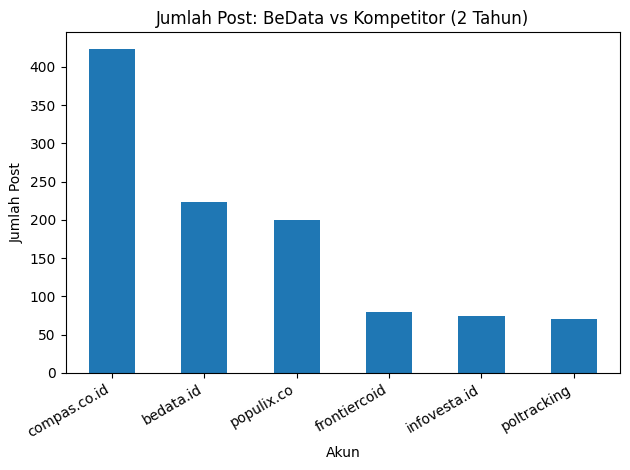

In [16]:
post_counts = df.groupby("ownerUsername")["caption"].count().sort_values(ascending=False)

plt.figure()
post_counts.plot(kind="bar")
plt.title("Jumlah Post: BeData vs Kompetitor (2 Tahun)")
plt.xlabel("Akun")
plt.ylabel("Jumlah Post")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


Dari semua kompetitor `compas.co` memiliki keunggulan dalam jumlah post pada periode 2 tahun terakhir, namun `BeData` menempati posisi kedua sehingga sudah bisa dianggap konsisten pada branding di instagram melalui banyak post yang dilakukan.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

BEDATA = "bedata.id"
COMPETITORS = [
    "compas.co.id",
    "frontiercoid",
    "poltracking",
    "infovesta.id",
    "populix.co",
]

df_bedata = df[df["ownerUsername"] == BEDATA].copy()


In [18]:
import plotly.io as pio
pio.renderers.default = "vscode"


In [19]:
import pandas as pd
import plotly.express as px

owners = OWNERS
target_order = ["business_corporate", "general", "government_politics", "academic", "public"]

# hitung % per owner-target
target_count = (
    df.groupby(["ownerUsername", "target_market"])
      .size()
      .reset_index(name="count")
)
target_count["total"] = target_count.groupby("ownerUsername")["count"].transform("sum")
target_count["pct"] = (target_count["count"] / target_count["total"]) * 100

# wide table (%)
target_pct = (
    target_count
    .pivot(index="ownerUsername", columns="target_market", values="pct")
    .fillna(0)
    .reindex(owners)
    .reindex(columns=target_order, fill_value=0)
)

# long table (untuk plotly)
plot_df_target = target_pct.reset_index().melt(
    id_vars="ownerUsername", var_name="target_market", value_name="pct"
)

display(target_pct.round(1))
fig = px.bar(
    plot_df_target,
    x="target_market",
    y="pct",
    color="ownerUsername",
    barmode="group",
    category_orders={
        "ownerUsername": owners,
        "target_market": target_order
    },
    title="Distribusi Target Market: BeData vs Kompetitor"
)
fig.update_layout(yaxis_title="Persentase (%)", xaxis_title="Target Market")
fig.show()


target_market,business_corporate,general,government_politics,academic,public
ownerUsername,,,,,
frontiercoid,60.8,22.8,12.7,1.3,2.5
poltracking,1.4,31.4,67.1,0.0,0.0
infovesta.id,10.1,84.8,3.8,1.3,0.0
populix.co,53.0,17.0,17.5,2.0,10.5
bedata.id,24.1,49.1,9.8,14.3,2.7
compas.co.id,97.6,0.9,0.7,0.7,0.0


## Distribusi Target Market (BeData vs Kompetitor)
- **BeData** paling dominan di **general (~49%)**, lalu **business_corporate (~24%)** dan **academic (~14%)**; sisanya kecil di **government_politics (~10%)** dan **public (~3%)**.
- Pola kompetitor terlihat “spesialis”:
  - **compas.co.id** hampir full **business_corporate (~98%)**.
  - **infovesta.id** dominan **general (~85%)**.
  - **poltracking** dominan **government_politics (~67%)**.
  - **populix.co** campuran **business_corporate (~53%)** + **general/government (~17–18%)**.
  - **frontiercoid** condong **business_corporate (~61%)**.

In [20]:
cta_order = ["no_cta", "sales_led", "product_led", "engagement"]

cta_count = (
    df.groupby(["ownerUsername", "cta_type"])
      .size()
      .reset_index(name="count")
)
cta_count["total"] = cta_count.groupby("ownerUsername")["count"].transform("sum")
cta_count["pct"] = (cta_count["count"] / cta_count["total"]) * 100

cta_pct = (
    cta_count
    .pivot(index="ownerUsername", columns="cta_type", values="pct")
    .fillna(0)
    .reindex(owners)
    .reindex(columns=cta_order, fill_value=0)
)

plot_df_cta = cta_pct.reset_index().melt(
    id_vars="ownerUsername", var_name="cta_type", value_name="pct"
)

display(cta_pct.round(1))
fig = px.bar(
    plot_df_cta,
    x="cta_type",
    y="pct",
    color="ownerUsername",
    barmode="group",
    category_orders={
        "ownerUsername": owners,
        "cta_type": cta_order
    },
    title="Distribusi CTA Type: BeData vs Kompetitor"
)
fig.update_layout(yaxis_title="Persentase (%)", xaxis_title="CTA Type")
fig.show()


cta_type,no_cta,sales_led,product_led,engagement
ownerUsername,,,,
frontiercoid,68.4,10.1,11.4,10.1
poltracking,97.1,2.9,0.0,0.0
infovesta.id,88.6,7.6,2.5,1.3
populix.co,52.5,16.0,26.5,5.0
bedata.id,64.7,12.1,11.2,12.1
compas.co.id,28.5,46.2,20.3,5.0


## Distribusi CTA Type
- Mayoritas akun masih **no_cta** (termasuk **BeData ~65%**).
- **BeData** relatif lebih **seimbang** di CTA lain: **sales_led (~12%)**, **product_led (~11%)**, **engagement (~12%)** (tidak “mentok” di no_cta seperti poltracking/infovesta).
- **compas.co.id** paling agresif konversi: **sales_led tinggi (~46%)** dan **no_cta lebih rendah (~29%)**.
- **populix.co** menonjol di **product_led (~27%)** (lebih “product-driven”).


In [21]:
label_order = [
    "business_offering",
    "respondent_acquisition",
    "methodology_trust",
    "brand_legitimacy",
    "event_activation",
    "political_domain",
    "other"
]

df_labels = df.explode("caption_labels").rename(columns={"caption_labels": "caption_label"})

label_count = (
    df_labels.groupby(["ownerUsername", "caption_label"])
             .size()
             .reset_index(name="count")
)
label_count["total"] = label_count.groupby("ownerUsername")["count"].transform("sum")
label_count["pct"] = (label_count["count"] / label_count["total"]) * 100

label_pct = (
    label_count
    .pivot(index="ownerUsername", columns="caption_label", values="pct")
    .fillna(0)
    .reindex(owners)
    .reindex(columns=label_order, fill_value=0)
)

plot_df_label = label_pct.reset_index().melt(
    id_vars="ownerUsername", var_name="caption_label", value_name="pct"
)

display(label_pct.round(1))
fig = px.bar(
    plot_df_label,
    x="caption_label",
    y="pct",
    color="ownerUsername",
    barmode="group",
    category_orders={
        "ownerUsername": owners,
        "caption_label": label_order
    },
    title="Distribusi Caption Label: BeData vs Kompetitor"
)
fig.update_layout(yaxis_title="Persentase (%)", xaxis_title="Caption Label")
fig.update_xaxes(tickangle=25)
fig.show()



caption_label,business_offering,respondent_acquisition,methodology_trust,brand_legitimacy,event_activation,political_domain,other
ownerUsername,,,,,,,
frontiercoid,27.0,25.5,10.6,11.3,2.1,5.0,18.4
poltracking,14.4,19.2,6.8,0.7,18.5,28.8,11.6
infovesta.id,12.4,10.3,0.0,5.2,16.5,3.1,52.6
populix.co,26.0,27.8,3.5,10.0,19.5,6.8,6.5
bedata.id,21.4,13.4,5.2,6.2,5.5,5.5,42.8
compas.co.id,42.5,20.4,6.4,10.8,8.1,0.6,11.3


## Distribusi Caption Label
- **BeData** didominasi **other (~43%)**, lalu **business_offering (~21%)** dan **respondent_acquisition (~13%)**; label lain relatif kecil (≤6%).
- Ciri khas kompetitor:
  - **poltracking** kuat di **political_domain (~29%)** + **event_activation (~18%)**.
  - **compas.co.id** kuat di **business_offering (~42%)**.
  - **infovesta.id** sangat tinggi di **other (~52%)** (konten beragam/tidak banyak masuk kategori spesifik).
  - **populix.co** cukup merata, puncak di **respondent_acquisition (~28%)**.

## Insight utama untuk BeData
- **Positioning**: lebih “mainstream” (**general + business**) dengan keunikan **academic** yang relatif lebih besar dibanding kompetitor.
- **Gap paling jelas** vs pemain paling konversi (compas): **porsi no_cta masih tinggi**.
- Dominasi label **“other”** bisa berarti **messaging belum terkonsolidasi** atau **skema label terlalu kasar**.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

PATH = "C:/MAGANG/Project/210120026-BeData/Raw Data/dataset_instagram-scraper_2026-01-28_13-46-33-230.csv"
TZ = "Asia/Jakarta"

FOCUS_ACCOUNTS = [
    "frontiercoid",
    "poltracking",
    "infovesta.id",
    "populix.co",
    "bedata.id",
    "compas.co.id",
]

AGG = "mean"          # "mean" atau "median" (median biasanya lebih stabil)
SMOOTH_MONTHS = 3     # 1 = tanpa smoothing, 3 = rolling 3 bulan biar lebih smooth & gampang dibaca

# =======================
# LOAD 
# =======================
cols = pd.read_csv(PATH, nrows=0).columns
need = [c for c in ["ownerUsername","timestamp","likesCount","commentsCount"] if c in cols]
df = pd.read_csv(PATH, usecols=need, low_memory=False)

# =======================
# CLEAN
# =======================
df["likesCount"] = pd.to_numeric(df["likesCount"], errors="coerce")
df["commentsCount"] = pd.to_numeric(df["commentsCount"], errors="coerce")
df.loc[df["likesCount"] < 0, "likesCount"] = np.nan
df.loc[df["commentsCount"] < 0, "commentsCount"] = np.nan

df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce").dt.tz_convert(TZ)
df = df.dropna(subset=["timestamp","ownerUsername"]).copy()

df = df[df["ownerUsername"].isin(FOCUS_ACCOUNTS)].copy()
df["engagement"] = df["likesCount"] + df["commentsCount"]

# =======================
# MONTHLY AGGREGATION
# =======================
df = df.set_index("timestamp").sort_index()

g = df.groupby("ownerUsername")[["likesCount","commentsCount","engagement"]].resample("MS")
monthly = (g.mean() if AGG == "mean" else g.median()).reset_index()

def pivot_metric(metric: str) -> pd.DataFrame:
    wide = (monthly.pivot(index="timestamp", columns="ownerUsername", values=metric)
                  .sort_index())
    # pastikan urutan kolom sesuai FOCUS_ACCOUNTS
    wide = wide.reindex(columns=[a for a in FOCUS_ACCOUNTS if a in wide.columns])
    # smoothing sederhana (rolling per akun)
    if SMOOTH_MONTHS and SMOOTH_MONTHS > 1:
        wide = wide.rolling(SMOOTH_MONTHS, min_periods=1).mean()
    return wide

likes_w = pivot_metric("likesCount")
comments_w = pivot_metric("commentsCount")
eng_w = pivot_metric("engagement")


def plot_easy(wide: pd.DataFrame, title: str, ylabel: str):
    fig, ax = plt.subplots(figsize=(12, 5))

    for acc in wide.columns:
        y = wide[acc]
        line, = ax.plot(wide.index, y, marker="o", linewidth=2, markersize=3, label=acc)

        # label di ujung 
        last_valid = y.last_valid_index()
        if last_valid is not None:
            ax.text(
                last_valid, y.loc[last_valid],
                f"  {acc}",
                fontsize=9,
                va="center",
                color=line.get_color()
            )

    ax.set_title(title)
    ax.set_xlabel("Bulan")
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.3)

    # format tanggal biar rapi
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # tiap 2 bulan
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45, ha="right")

    # Legend opsional 
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

    plt.tight_layout()
    plt.show()

suffix = f"({AGG}, smooth={SMOOTH_MONTHS} bulan)" if SMOOTH_MONTHS and SMOOTH_MONTHS > 1 else f"({AGG})"


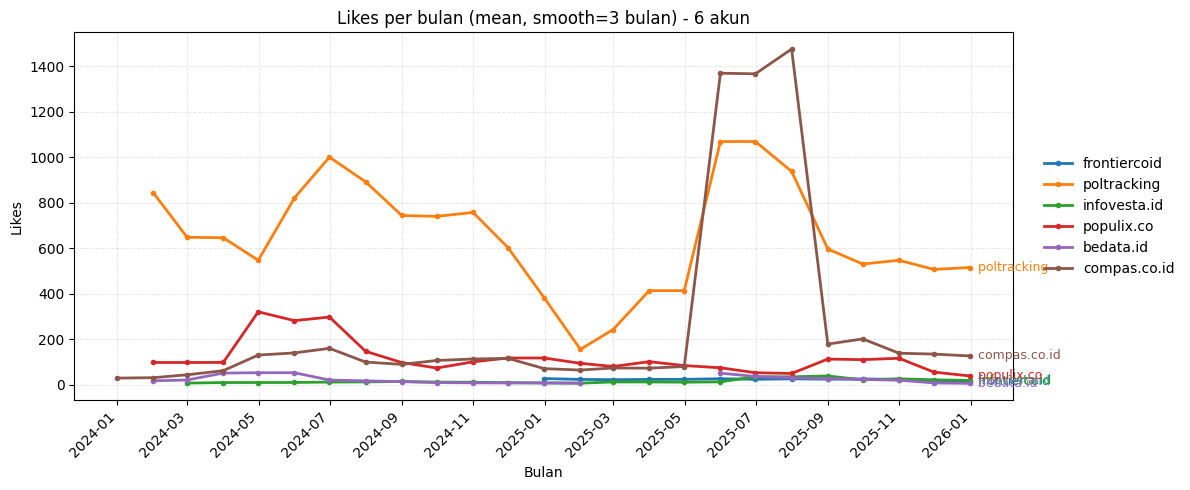

In [23]:
plot_easy(likes_w,    f"Likes per bulan {suffix} - 6 akun",        "Likes")

## Likes per bulan 
- **Paling banyak likes secara konsisten:** `poltracking` biasanya yang tertinggi sepanjang waktu.
- **Lonjakan besar tapi cuma sementara:** `compas.co.id` sempat **meledak** sekitar Jul–Sep 2025 (likes sangat tinggi), tapi habis itu **turun lagi** ke level normal. Ini tanda ada konten/event yang viral, bukan naik stabil.
- **Sedang:** `populix.co` sempat tinggi di pertengahan 2024, lalu turun dan cenderung stabil di angka menengah.
- **Rendah:** `frontiercoid`, `infovesta.id`, dan **`bedata.id`** cenderung rendah dan datar (tidak ada kenaikan besar yang bertahan lama).

Kenaikan dan lonjakan yang terjadi pada poltracking sendiri mungkin dapat terjadi karena adanya isu politik yang sedang memanas, karena dari insight sebelumnya didapatkan bahwa poltracking sendiri lebih banyak berfokus pada bidang politik

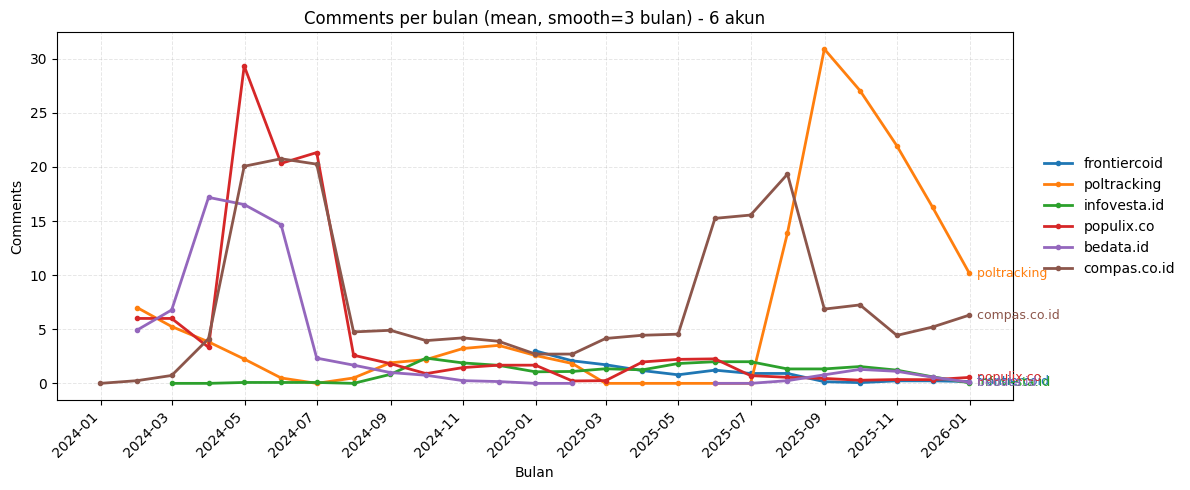

In [24]:
plot_easy(comments_w, f"Comments per bulan {suffix} - 6 akun",     "Comments")

## Comments per bulan
- **Komentar paling “rame” tapi pada momen tertentu:**
  - `populix.co` sempat sangat tinggi sekitar Mei 2024, lalu turun tajam.
  - `bedata.id` juga sempat tinggi sekitar Apr–Jun 2024, lalu turun dan kecil.
- **Gelombang komentar besar:** `poltracking` meledak sekitar Sep 2025 (komentar tinggi), lalu turun pelan-pelan setelahnya → biasanya karena isu/topik panas.
- `compas.co.id` juga pernah tinggi di pertengahan 2024 dan naik lagi sekitar Jun–Sep 2025, tapi tidak setinggi lonjakan likes-nya.

Kenaikan dan lonjakan yang terjadi pada poltracking sendiri mungkin dapat terjadi karena adanya isu politik yang sedang memanas, karena dari insight sebelumnya didapatkan bahwa poltracking sendiri lebih banyak berfokus pada bidang politik

# ======================================================================

In [25]:
COMMENT_FILES = {
    "bedata.id": "C:/MAGANG/Project/210120026-BeData/Raw Data/komen_bedata.csv",
    "compas.co.id": "C:/MAGANG/Project/210120026-BeData/Raw Data/komen_compas.csv",
    "frontiercoid": "C:/MAGANG/Project/210120026-BeData/Raw Data/komen_frontier.csv",
    "infovesta.id": "C:/MAGANG/Project/210120026-BeData/Raw Data/komen_infovesta.csv",
    "poltracking": "C:/MAGANG/Project/210120026-BeData/Raw Data/komen_poltracking.csv",
    "populix.co": "C:/MAGANG/Project/210120026-BeData/Raw Data/komen_populix.csv"
}

# Lokasi file dataset utama
POST_FILE = "C:/MAGANG/Project/210120026-BeData/Raw Data/dataset_post.csv"
SCRAPER_FILE = "C:/MAGANG/Project/210120026-BeData/Raw Data/dataset_instagram-scraper_2026-01-28_13-46-33-230.csv"

In [26]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import CountVectorizer
import warnings

warnings.filterwarnings("ignore")

In [27]:
# FILTERING: PATTERNS UCAPAN (GREETINGS)

GREETING_PATTERNS = [
    # Ulang Tahun & Perayaan Pribadi
    r"selamat ulang tahun", r"happy birthday", r"hbd", r"met milad", r"barakallah",
    r"panjang umur", r"sehat selalu", r"wish you all the best", r"wuatb",
    r"dirgahayu", r"hut ke", r"anniversary", r"happy anniversary",
    
    # Hari Besar Keagamaan/Nasional
    r"selamat hari", r"hari raya", r"idul fitri", r"idul adha", r"lebaran",
    r"natal", r"christmas", r"tahun baru", r"happy new year", r"imlek",
    r"merdeka", r"kemerdekaan",
    
    # Ucapan Selamat Umum
    r"congratulations", r"congrats", r"selamat atas", r"sukses selalu",
    r"turut berduka", r"rip", r"innalillahi",
    
    # Spam Sapaan Standar
    r"selamat pagi", r"semangat pagi", 
    r"terimakasih info", r"thx info", r"nice info", r"thanks info"
]

In [28]:
EXPANDED_KEYWORDS = {
    "H1_Surveyor_Fisik": [
        r"surveyor", r"enumerator", r"pencacah", r"petugas survei", 
        r"tim lapangan", r"tenaga lapangan", r"koordinator lapangan",
        r"korlap", r"verifikator", r"data lapangan", r"sensus",
        r"turun ke jalan", r"door to door", r"wawancara langsung",
        r"cek lokasi", r"tinjau lokasi", r"visit", r"kunjungan",
        r"responden fisik", r"tatap muka",
        r"tps", r"quick count", r"hitung cepat", r"saksi", r"relawan"
    ],
    "Biz_Revenue_Signal": [
        r"harga", r"biaya", r"cost", r"budget", r"anggaran", r"tarif",
        r"bayar", r"fee", r"tagihan", r"invoice", r"transaksi",
        r"berbayar", r"premium", r"langganan", r"subscribe",
        r"pricelist", r"rate card", r"proposal", r"penawaran", r"diskon",
        r"promo", r"paket", r"bundling", r"kerjasama", r"partnership",
        r"mahal", r"murah", r"terjangkau", r"worth it", r"boncos"
    ],
    "Weakness_Complain": [
        r"lambat", r"kacang", 
        r"slow respon", r"gak dibales", r"no respon", r"menunggu",
        r"error", r"bug", r"gagal", r"nggak bisa", r"tidak bisa", r"down",
        r"lemot", r"lag", r"force close", r"susah login", r"otp",
        r"kecewa", r"penipuan", r"scam", r"hoax", r"bohong", r"palsu",
        r"rugi", r"nyesel", r"ribet", r"zonk", r"php", r"parah"
    ],
    "Strength_Engagement": [
        r"kode", r"referral", r"undangan", r"ajak teman", r"poin", 
        r"reward", r"hadiah", r"saldo", r"voucher", r"pulsa",
        r"gopay", r"ovo", r"dana", r"shopeepay", r"ewallet", 
        r"tarik dana", r"withdraw", r"wd", r"cair", r"cuan",
        r"keren", r"mantap", r"bermanfaat", r"insight", r"daging",
        r"ilmu", r"belajar", r"terbantu", r"akurat", r"valid"
    ]
}

In [29]:
def clean_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', '', text) 
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def is_greeting(text):
    if not isinstance(text, str): return False
    text = text.lower()
    pattern = "|".join(GREETING_PATTERNS)
    return bool(re.search(pattern, text))

def run_analysis_filtered(file_map, keywords):
    results = []
    
    # Stopwords (Kata umum yang dibuang saat deteksi topik otomatis)
    stop_words_id = list(['yang', 'dan', 'di', 'ke', 'dari', 'ini', 'itu', 'untuk', 'ya', 'nya', 
                          'yg', 'gak', 'kak', 'min', 'aku', 'bisa', 'ada', 'mau', 'sama', 'juga', 
                          'kok', 'banget', 'tapi', 'kalau', 'kalo', 'sudah', 'lagi', 'apa', 'pada',
                          'terima', 'kasih', 'banyak', 'dong', 'sih', 'lah'])

    print(f"{'Kompetitor':<15} | {'Data Awal':<10} | {'Data Bersih'}")
    print("-" * 50)

    for owner, filename in file_map.items():
        try:
            df = pd.read_csv(filename)
            text_col = next((c for c in df.columns if 'text' in c.lower() or 'caption' in c.lower()), None)
            
            if not text_col: continue

            # 1. PREPROCESSING
            df['clean'] = df[text_col].apply(clean_text)
            
            # 2. FILTERING (BUANG GREETINGS)
            initial_count = len(df)
            df_clean = df[~df[text_col].apply(is_greeting)] # Simpan yang BUKAN greeting
            final_count = len(df_clean)
            
            print(f"{owner:<15} | {initial_count:<10} | {final_count}")

            # 3. KEYWORD MATCHING
            row_data = {"Competitor": owner}
            for category, patterns in keywords.items():
                pattern = "|".join(patterns)
                matches = df_clean[df_clean['clean'].str.contains(pattern, regex=True, na=False)]
                count = len(matches)
                row_data[category] = count
                
                # Ambil Bukti Terbaik
                evidence = "-"
                if count > 0:
                    matches['length'] = matches[text_col].astype(str).str.len()
                    best_match = matches.sort_values('length', ascending=False).iloc[0]
                    raw_text = str(best_match[text_col])
                    evidence = (raw_text[::] + '...')
                row_data[f"Bukti_{category}"] = evidence

            # 4. TOPIC MODELING (AUTOMATED)
            docs = df_clean[text_col].dropna().astype(str).tolist()
            top_topics = "-"
            if len(docs) >= 5:
                # Cari frase 2-3 kata yang paling sering muncul
                c_vec = CountVectorizer(stop_words=stop_words_id, ngram_range=(2, 3))
                ngrams = c_vec.fit_transform(docs)
                count_values = ngrams.toarray().sum(axis=0)
                vocab = c_vec.vocabulary_
                sorted_ngrams = sorted([(k, count_values[v]) for k, v in vocab.items()], key=lambda x: x[1], reverse=True)
                top_topics = ", ".join([f"{w}" for w, c in sorted_ngrams[:4]])
            
            row_data["Topik_Dominan_Otomatis"] = top_topics
            results.append(row_data)

        except Exception as e:
            print(f"Error {owner}: {e}")

    return pd.DataFrame(results)

In [30]:

df_final = run_analysis_filtered(COMMENT_FILES, EXPANDED_KEYWORDS)

Kompetitor      | Data Awal  | Data Bersih
--------------------------------------------------
bedata.id       | 201        | 186
compas.co.id    | 835        | 794
frontiercoid    | 32         | 31
infovesta.id    | 57         | 42
poltracking     | 355        | 322
populix.co      | 161        | 155


# KOMENTAR

In [31]:
print("\n=== RINGKASAN INSIGHT (CLEAN DATA) ===")
cols_summary = ['Competitor', 'H1_Surveyor_Fisik', 'Biz_Revenue_Signal', 'Weakness_Complain', 'Topik_Dominan_Otomatis']
df_final[cols_summary]


=== RINGKASAN INSIGHT (CLEAN DATA) ===


,Competitor,H1_Surveyor_Fisik,Biz_Revenue_Signal,Weakness_Complain,Topik_Dominan_Otomatis
0,bedata.id,0,3,3,"of course, can you, you send, send me"
1,compas.co.id,1,15,16,"ms glow, camille beauty, bromen official, white inc"
2,frontiercoid,0,6,3,"sinyal jaringan, varian paket, paket berbeda, berbeda pula"
3,infovesta.id,0,0,1,"reksadana indeks, indeks infovesta28, reksadana indeks infovesta28, agar segera"
4,poltracking,26,3,5,"quick count, hasil evaluasi, count psu, quick count psu"
5,populix.co,0,4,6,"cek dm, send me, me this, this post"


- Dari hasil tersebut dapat dikatakan bahwa hanya ``poltracking`` yang secara terbuka terbukti menggunakan **surveyor fisik** yang dilakukan untuk quick count. Kompetitor lain melakukkannya secara digital.

- Untuk segmentasi pasar atau pembahasan, `Compas` berfokus pada produk produk seperti make up dan sebagainya, kemudian untuk `Infovesta` berfokus pada produk finansial dan keuangan, `Frontier` sendiri banyak pembahasan mengenai sinyal jaringan.

In [32]:
from IPython.display import display
print("\n=== BUKTI SURVEYOR FISIK ===")
display(df_final[['Competitor', 'Bukti_H1_Surveyor_Fisik']])



=== BUKTI SURVEYOR FISIK ===


,Competitor,Bukti_H1_Surveyor_Fisik
0,bedata.id,-
1,compas.co.id,seru bgt!! semoga kunjungan ini melahirkan project & kolaborasi yang mengedukasi ++ bermanfaat🙌👏...
2,frontiercoid,-
3,infovesta.id,-
4,poltracking,Apresiasi setinggi-tingginya untuk Poltracking atas pelaksanaan quick count yang transparan dan akurat. Ini adalah b...
5,populix.co,-


- `Poltracking` → satu-satunya yang menunjukkan bukti operasional lapangan yang jelas dan relevan.

- `Compas.co.id` → ada indikasi kunjungan, belum bukti operasional.

- `Bedata.id`, `Frontiercoid`, `Infovesta.id`, `Populix.co` → tidak ada bukti lapangan yang ditampilkan.

In [33]:
print("\n=== BUKTI REVENUE SIGNAL ===")
display(df_final[['Competitor', 'Bukti_Biz_Revenue_Signal']])


=== BUKTI REVENUE SIGNAL ===


,Competitor,Bukti_Biz_Revenue_Signal
0,bedata.id,First min dapet diskon olah data ga sih minn 🔥...
1,compas.co.id,"Dari dulu mager bgt pake sunscreen krn selalu bikin nyumbat pori, semenjak pake wardah jadi CINTA bangett karna supe..."
2,frontiercoid,Operator memiliki lebih dari satu produk tapi apakah sinyal jaringan memiliki skala pemancar yang sama? Kan berbeda ...
3,infovesta.id,-
4,poltracking,Quick Count adalah alat penting untuk transparansi pemilu. Mari kita tunggu hasil resmi sambil menghargai setiap sua...
5,populix.co,tidak efektif tapi bagus buat perekonomian dari biaya cetak biaya pasang baliho dan nambabin kerja satpol pp klo sd...


- Tidak ada competitor yang menunjukkan sinyal revenue yang jelas, langsung, dan terverifikasi.

- Isi kolom didominasi opini umum, analogi, atau komentar sosial, bukan indikator bisnis.

 - `Poltracking` & `Compas` menyebut konteks aktivitas (quick count/produk), tapi tanpa implikasi pendapatan.

In [34]:
print("\n=== BUKTI WEAKNESS COMPLAIN ===")
display(df_final[['Competitor', 'Bukti_Weakness_Complain']])


=== BUKTI WEAKNESS COMPLAIN ===


,Competitor,Bukti_Weakness_Complain
0,bedata.id,"ganti judul, ganti variabel, revisi bab1 yang ga kelar kelar🥲 belum lagi liat kawan kawan seperjuangan udah selesai ..."
1,compas.co.id,Dari anakku mulai Mpasi sampai sekarang udh 2 tahun aku selalu pakai @myyummybites dan gk tau kenapa anakku juga coc...
2,frontiercoid,apalagi ada brand pesaing seperti wings dimana mereka punya money value yang lebih terjangkau. pasti banyak masyarak...
3,infovesta.id,"Semoga secepatnya diluncurkan Reksadana indeks infovesta28 ya min, dan mudah2an dipasarkan di aplikasi BIBIT. Soalny..."
4,poltracking,"Hasil Evaluasi Kinerja pemerintahan Prabowo Gibran emang lagi ditunggu tunggu, nggak terasa ya pemerintahan ini udah..."
5,populix.co,Coba untuk populix tolong diperhatikan beberapa hal yang saya tulis ini. 1. bug reward 1 poin isi 10 poppol mingguan...


- `Populix.co` → keluhan paling konkret dan operasional (bug sistem, reward, standar survey).

- `Bedata.id` → masalah atau oborlan internal/proses kerja .

- `Frontiercoid` → tekanan kompetitif harga/value, indikasi posisi pasar lemah, namun terkait pada produk lain bukan pada frontiernya.

- `Compas.co.id`, `Infovesta.id`, `Poltracking` → tidak ada keluhan relevan (konten tidak terkait produk/jasa inti).

# ==========================================================================

# WEBSITE

In [36]:
# =========================================
# CELL 1 — Setup & Load Data
# =========================================
import pandas as pd
import numpy as np
import ast
import re
from pathlib import Path
import matplotlib.pyplot as plt

DATA_PATH = Path("C:/MAGANG/Project/210120026-BeData/Data Bersih/web_clean.csv")  

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Shape: (485, 6)
Columns: ['url', 'text', 'competitor', 'clean_text', 'text_indo', 'kategori_analisis']


,url,text,competitor,clean_text,text_indo,kategori_analisis
0,https://compas.co.id/fmcg-market-insight-dashboard/,"E-Commerce Market Insight Dashboard - Compas\nCompas.co.id Market Insight Dashboard offers advanced, data-driven too...",Compas,E-Commerce Market Insight Dashboard - Compas,Dasbor Wawasan Pasar E-Commerce - Kompas,['Lainnya']
1,https://compas.co.id/fmcg-market-insight-dashboard/,"E-Commerce Market Insight Dashboard - Compas\nCompas.co.id Market Insight Dashboard offers advanced, data-driven too...",Compas,"Compas.co.id Market Insight Dashboard offers advanced, data-driven tools designed to empower FMCG brands in the comp...",Dashboard Market Insight Kompas.co.id menawarkan alat canggih berbasis data yang dirancang untuk memberdayakan merek...,"['Produk & Layanan', 'Target Pasar']"
2,https://compas.co.id/fmcg-market-insight-dashboard/,"E-Commerce Market Insight Dashboard - Compas\nCompas.co.id Market Insight Dashboard offers advanced, data-driven too...",Compas,"Compas.co.id Market Insight Dashboard is designed to tackle these challenges head-on, providing FMCG brands with rea...","Dasbor Wawasan Pasar Compas.co.id dirancang untuk mengatasi tantangan-tantangan ini secara langsung, menyediakan dat...","['Produk & Layanan', 'Target Pasar', 'Kelebihan & Kekurangan']"
3,https://compas.co.id/fmcg-market-insight-dashboard/,"E-Commerce Market Insight Dashboard - Compas\nCompas.co.id Market Insight Dashboard offers advanced, data-driven too...",Compas,"Gain a complete understanding of your brand’s market position with insights into market share, category trends, and ...","Dapatkan pemahaman lengkap tentang posisi pasar merek Anda dengan wawasan tentang pangsa pasar, tren kategori, dan k...","['Produk & Layanan', 'Kelebihan & Kekurangan']"
4,https://compas.co.id/llms.txt,Services Product Market Insight \nAbout Us Insights Articles Career Contact Us ID EN Contact Us Request Demo\nServi...,Compas,Services Product Market Insight,Wawasan Pasar Produk Jasa,['Produk & Layanan']


In [37]:
# =========================================
# CELL 2 — Basic Checks
# =========================================
print("Missing values (top):")
display(df.isna().sum().sort_values(ascending=False).head(15))

print("\nCompetitor distribution:")
display(df["competitor"].value_counts())

# pilih kolom teks yang tersedia
TEXT_COL = "clean_text" if "clean_text" in df.columns else "text_indo"
print("\nTEXT_COL used:", TEXT_COL)


Missing values (top):


url                  0
text                 0
competitor           0
clean_text           0
text_indo            0
kategori_analisis    0
dtype: int64


Competitor distribution:


competitor
Populix        255
Frontier       112
Infovesta       70
Compas          43
Poltracking      5
Name: count, dtype: int64


TEXT_COL used: clean_text


In [ ]:
df = df.drop_duplicates()

In [39]:
# =========================================
# CELL 3 — Parse kategori_analisis jadi list
# =========================================
def parse_kategori(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)  # contoh: "['Produk & Layanan']"
        except Exception:
            return [x]
    return ["Lainnya"]

df["kategori_list"] = df["kategori_analisis"].apply(parse_kategori)

all_cats = sorted({c for lst in df["kategori_list"] for c in (lst if isinstance(lst, list) else [])})
print("Kategori unik:", all_cats)


Kategori unik: ['Kelebihan & Kekurangan', 'Lainnya', 'Model Bisnis', 'Produk & Layanan', 'Revenue & Harga', 'Target Pasar']


In [40]:
# =========================================
# CELL 4 — Coverage kategori per competitor (pivot)
# =========================================
dx = df.explode("kategori_list").rename(columns={"kategori_list": "kategori"})

pivot = (dx.pivot_table(index="competitor", columns="kategori", values="url",
                        aggfunc="count", fill_value=0)
           .sort_index())

display(pivot)


kategori,Kelebihan & Kekurangan,Lainnya,Model Bisnis,Produk & Layanan,Revenue & Harga,Target Pasar
competitor,,,,,,
Compas,7,10,1,32,10,12
Frontier,5,51,4,49,11,25
Infovesta,20,22,0,40,6,22
Poltracking,2,0,0,4,0,1
Populix,32,109,27,89,25,33


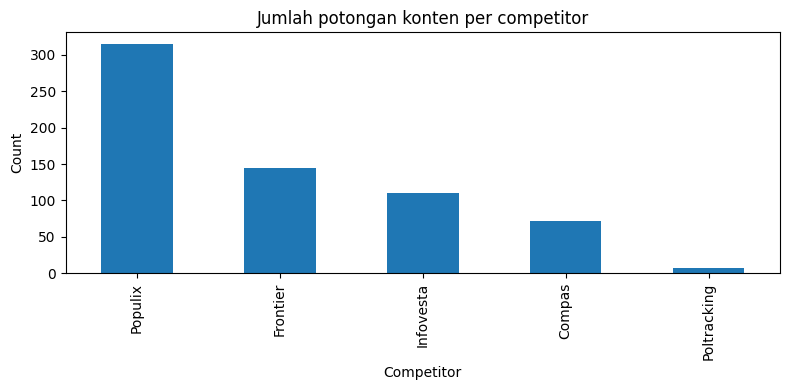

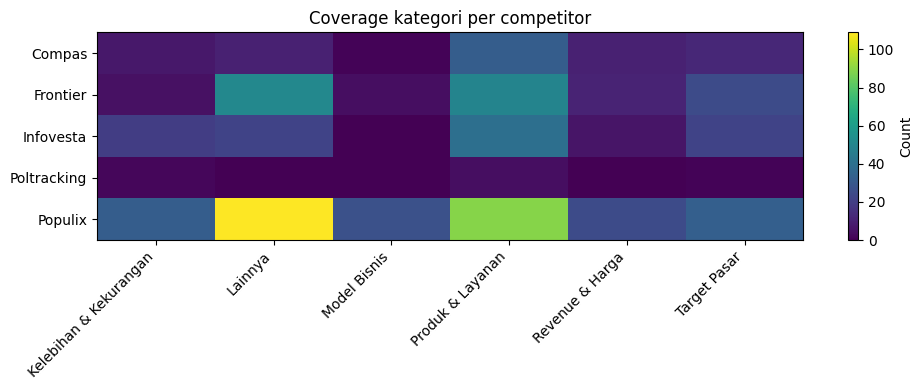

In [41]:
# =========================================
# CELL 5 — Visualisasi: bar total & heatmap coverage
# =========================================
totals = pivot.sum(axis=1).sort_values(ascending=False)

plt.figure(figsize=(8,4))
totals.plot(kind="bar")
plt.title("Jumlah potongan konten per competitor")
plt.xlabel("Competitor")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.imshow(pivot.values, aspect="auto")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha="right")
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label="Count")
plt.title("Coverage kategori per competitor")
plt.tight_layout()
plt.show()


In [42]:
# =========================================
# CELL 6 — TF-IDF: top keywords per competitor
# =========================================
from sklearn.feature_extraction.text import TfidfVectorizer

def top_tfidf_terms(texts, top_n=15):
    texts = [t for t in texts if isinstance(t, str) and t.strip()]
    if len(texts) < 3:
        return []
    vec = TfidfVectorizer(
        max_features=4000,
        ngram_range=(1, 2),
        stop_words=None
    )
    X = vec.fit_transform(texts)
    terms = np.array(vec.get_feature_names_out())
    scores = np.asarray(X.mean(axis=0)).ravel()
    top_idx = scores.argsort()[::-1][:top_n]
    return list(zip(terms[top_idx], scores[top_idx]))

kw_comp = {}
for comp, g in df.groupby("competitor"):
    kw_comp[comp] = top_tfidf_terms(g[TEXT_COL].tolist(), top_n=20)

rows = []
for comp, kws in kw_comp.items():
    rows.append({"competitor": comp, "top_terms": ", ".join([t for t,_ in kws[:12]])})

kw_table = pd.DataFrame(rows).sort_values("competitor")
display(kw_table)


,competitor,top_terms
0,Compas,"compas, co, id, co id, market, compas co, commerce, insight, market insight, var, services, data"
1,Frontier,"research, frontier, and, in, to, marketing, indonesia, brand, frontier research, business, technology, education"
2,Infovesta,"investpro, yang, kami, to, the, data, and, investasi, investment, dan, oforu, untuk"
3,Poltracking,"services, services poltracking, poltracking, quick count, count, quick, media, dan, digital, media digital, medmon, ..."
4,Populix,"solusi, untuk, survei, dan, anda, dengan, riset, yang, responden, kami, populix, di"


In [43]:
# =========================================
# CELL 7 — Rule-based signals untuk insight cepat (panel/pricing/B2B/dll)
# =========================================
SIGNALS = {
    "Target Responden/Panel": [
        r"responden", r"panel", r"panelis", r"insentif", r"reward",
        r"surveyors?", r"enumerator", r"field", r"komunitas", r"member"
    ],
    "B2B/B2C": [
        r"enterprise", r"business", r"b2b", r"b2c", r"ukm", r"sme", r"brand", r"perusahaan"
    ],
    "Pricing/Revenue": [
        r"pricing", r"harga", r"subscription", r"berlangganan", r"paket", r"plan",
        r"fee", r"commission", r"revenue", r"monetiz"
    ],
    "Produk/Layanan": [
        r"dashboard", r"insight", r"riset", r"research", r"survey", r"tracking",
        r"analytics", r"data", r"api", r"platform", r"saas"
    ],
    "Value Proposition": [
        r"faster", r"lebih cepat", r"akurasi", r"reliable", r"trusted",
        r"real[- ]?time", r"representative", r"methodolog", r"quality"
    ]
}

def count_signals(text, patterns):
    if not isinstance(text, str):
        return 0
    t = text.lower()
    return sum(len(re.findall(p, t)) for p in patterns)

sig_cols = list(SIGNALS.keys())
for k, pats in SIGNALS.items():
    df[k] = df[TEXT_COL].apply(lambda x: count_signals(x, pats))

display(df[sig_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
Target Responden/Panel,485.0,0.1,0.4,0.0,0.0,0.0,0.0,3.0
B2B/B2C,485.0,0.2,1.0,0.0,0.0,0.0,0.0,16.0
Pricing/Revenue,485.0,0.1,0.3,0.0,0.0,0.0,0.0,3.0
Produk/Layanan,485.0,0.7,1.8,0.0,0.0,0.0,1.0,27.0
Value Proposition,485.0,0.1,0.5,0.0,0.0,0.0,0.0,8.0


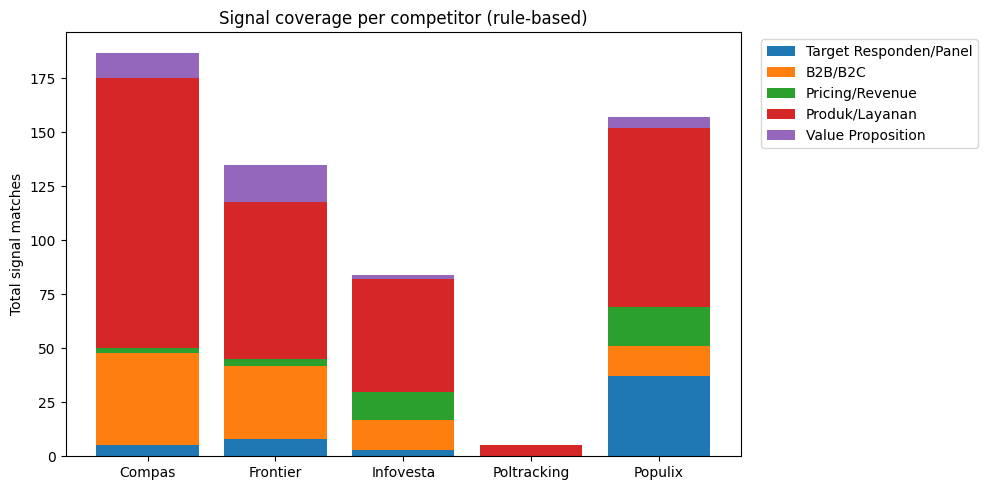

,Target Responden/Panel,B2B/B2C,Pricing/Revenue,Produk/Layanan,Value Proposition
competitor,,,,,
Compas,5,43,2,125,12
Frontier,8,34,3,73,17
Infovesta,3,14,13,52,2
Poltracking,0,0,0,5,0
Populix,37,14,18,83,5


In [44]:
# =========================================
# CELL 8 — Visualisasi signal coverage per competitor (stacked bar)
# =========================================
tot = df.groupby("competitor")[sig_cols].sum()

plt.figure(figsize=(10,5))
bottom = np.zeros(len(tot))
x = np.arange(len(tot.index))

for col in sig_cols:
    plt.bar(x, tot[col].values, bottom=bottom, label=col)
    bottom += tot[col].values

plt.xticks(x, tot.index)
plt.ylabel("Total signal matches")
plt.title("Signal coverage per competitor (rule-based)")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

display(tot.sort_index())


In [45]:
# =========================================
# CELL 9 — Evidence picker: ambil URL paling relevan per kategori fokus
# =========================================
def top_evidence(df_sub, category, n=5):
    sub = df_sub[df_sub["kategori_list"].apply(
        lambda lst: category in lst if isinstance(lst, list) else False
    )].copy()
    if sub.empty:
        return sub

    sub["evidence_score"] = sub[sig_cols].sum(axis=1) + (sub[TEXT_COL].fillna("").str.len() / 200.0)
    sub = sub.sort_values("evidence_score", ascending=False)

    cols = ["competitor", "url", "kategori_analisis", TEXT_COL] + sig_cols + ["evidence_score"]
    return sub[cols].head(n)

CATEGORIES_FOCUS = ["Model Bisnis", "Target Pasar", "Revenue & Harga", "Produk & Layanan", "Kelebihan & Kekurangan"]

evidence = []
for comp, g in df.groupby("competitor"):
    for cat in CATEGORIES_FOCUS:
        top = top_evidence(g, cat, n=3)
        if not top.empty:
            top = top.assign(focus_category=cat)
            evidence.append(top)

evidence_df = pd.concat(evidence, ignore_index=True) if evidence else pd.DataFrame()
display(evidence_df.head(25))

# simpan untuk dipakai di report
evidence_df.to_csv("evidence_top_links.csv", index=False)
print("Saved: evidence_top_links.csv")


,competitor,url,kategori_analisis,clean_text,Target Responden/Panel,B2B/B2C,Pricing/Revenue,Produk/Layanan,Value Proposition,evidence_score,focus_category
0,Compas,https://compas.co.id/llms.txt,"['Revenue & Harga', 'Produk & Layanan', 'Target Pasar', 'Model Bisnis', 'Kelebihan & Kekurangan']",Our Services Stop Drowning in DataStart Making Waves! Compas.co.id Market Insight gather all the essential e-commer...,3,16,1,27,8,76.3,Model Bisnis
1,Compas,https://compas.co.id/llms.txt,"['Revenue & Harga', 'Produk & Layanan', 'Target Pasar', 'Model Bisnis', 'Kelebihan & Kekurangan']",Our Services Stop Drowning in DataStart Making Waves! Compas.co.id Market Insight gather all the essential e-commer...,3,16,1,27,8,76.3,Target Pasar
2,Compas,https://compas.co.id/llms.txt,"['Revenue & Harga', 'Produk & Layanan', 'Target Pasar']","window.lazyLoadOptions=[{elements_selector:""img[data-lazy-src],.rocket-lazyload"",data_src:""lazy-src"",data_srcset:""la...",0,0,0,10,0,22.4,Target Pasar
3,Compas,https://compas.co.id/llms.txt,"['Revenue & Harga', 'Produk & Layanan', 'Target Pasar']",E-commerce EnablerBeauty InsightInsightTop Brand Top 10 Brand Kecantikan di Shopee Indonesia Kuartal I 2025: Tren Pa...,0,8,1,9,0,21.6,Target Pasar
4,Compas,https://compas.co.id/llms.txt,"['Revenue & Harga', 'Produk & Layanan', 'Target Pasar', 'Model Bisnis', 'Kelebihan & Kekurangan']",Our Services Stop Drowning in DataStart Making Waves! Compas.co.id Market Insight gather all the essential e-commer...,3,16,1,27,8,76.3,Revenue & Harga
5,Compas,https://compas.co.id/llms.txt,"['Revenue & Harga', 'Produk & Layanan', 'Target Pasar']","window.lazyLoadOptions=[{elements_selector:""img[data-lazy-src],.rocket-lazyload"",data_src:""lazy-src"",data_srcset:""la...",0,0,0,10,0,22.4,Revenue & Harga
6,Compas,https://compas.co.id/llms.txt,"['Revenue & Harga', 'Produk & Layanan', 'Target Pasar']",E-commerce EnablerBeauty InsightInsightTop Brand Top 10 Brand Kecantikan di Shopee Indonesia Kuartal I 2025: Tren Pa...,0,8,1,9,0,21.6,Revenue & Harga
7,Compas,https://compas.co.id/llms.txt,"['Revenue & Harga', 'Produk & Layanan', 'Target Pasar', 'Model Bisnis', 'Kelebihan & Kekurangan']",Our Services Stop Drowning in DataStart Making Waves! Compas.co.id Market Insight gather all the essential e-commer...,3,16,1,27,8,76.3,Produk & Layanan
8,Compas,https://compas.co.id/llms.txt,"['Revenue & Harga', 'Produk & Layanan', 'Target Pasar']","window.lazyLoadOptions=[{elements_selector:""img[data-lazy-src],.rocket-lazyload"",data_src:""lazy-src"",data_srcset:""la...",0,0,0,10,0,22.4,Produk & Layanan
9,Compas,https://compas.co.id/llms.txt,"['Revenue & Harga', 'Produk & Layanan', 'Target Pasar']",E-commerce EnablerBeauty InsightInsightTop Brand Top 10 Brand Kecantikan di Shopee Indonesia Kuartal I 2025: Tren Pa...,0,8,1,9,0,21.6,Produk & Layanan


Saved: evidence_top_links.csv
